In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import imageio
import mediapipe as mp
import cv2
import os
import tensorflow as tf
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
from tensorflow.keras.utils import to_categorical  # For converting labels to categorical format (one-hot encoding)
from tensorflow.keras.models import Sequential  # For defining the neural network architecture
from tensorflow.keras.layers import LSTM, Dense  # For adding LSTM and Dense layers to the model
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping  # For logging training progress for TensorBoard
from tensorflow.keras.models import load_model  # For loading pre-trained models
from tensorflow.keras.metrics import F1Score

In [2]:
# gloabl variables for label mapping
# removed j and z from this initial static classifier
static_label_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
static_label_map = {label: num for num, label in enumerate(static_label_names)}

In [3]:
# load train, validation, and test data

def load_split(split):
    images = []
    labels = []
    for label in static_label_names:
        image_paths = sorted(glob.glob(f'datasets/SignImages/{split}/{label}/*.jpg'))
        for path in image_paths:
            image = imageio.imread(path)
            images.append(image)
            labels.append(label)
    return np.array(images), np.array(labels)

train_images, train_labels = load_split('train')
val_images, val_labels = load_split('validation')
test_images, test_labels = load_split('test')

C:\Users\Ida\AppData\Local\Temp\ipykernel_26832\1722234016.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(path)


In [4]:
# extract landmarks from images using MediaPipe Hands (see examples/hands.py)

mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_hands = mp.solutions.hands

def extract_landmarks(images, labels):
    landmarks = []

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=2,
        min_detection_confidence=0.5) as hands:

        for image in images:
            results = hands.process(image)
            left = np.zeros(63)
            right = np.zeros(63)

            if results.multi_hand_landmarks and results.multi_handedness:
                for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
                    coords = np.array([[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark]).flatten()
                    if handedness.classification[0].label == 'Left':
                        left = coords
                    else:
                        right = coords
                features = np.concatenate([left, right])
                landmarks.append(features)
            else:
                landmarks.append(None)  # no hand detected

    # remove entries with no landmarks detected
    df = pd.DataFrame({
        'landmarks': landmarks,
        'label': labels
    })
    df = df[df['landmarks'].notna()]

    detected_landmarks = np.array(df['landmarks'].tolist())
    detected_labels = np.array(df['label'].values)

    ### TODO: when moving to dynamic signs, need to remove this repeat   ###
    ### repeat landmarks to create sequences of length 30 for LSTM input ###
    detected_landmarks = np.repeat(detected_landmarks[:, np.newaxis, :], 30, axis=1)

    return detected_landmarks, detected_labels

train_landmarks, train_labels = extract_landmarks(train_images, train_labels)
val_landmarks, val_labels = extract_landmarks(val_images, val_labels)
test_landmarks, test_labels = extract_landmarks(test_images, test_labels)

train_labels_int = np.array([static_label_map[l] for l in train_labels])
train_labels_cat = to_categorical(train_labels_int, num_classes=len(static_label_names))

val_labels_int = np.array([static_label_map[l] for l in val_labels])
val_labels_cat = to_categorical(val_labels_int, num_classes=len(static_label_names))

test_labels_int = np.array([static_label_map[l] for l in test_labels])
test_labels_cat = to_categorical(test_labels_int, num_classes=len(static_label_names))

In [5]:
# define LSTM model for static sign classification
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30, 126)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(static_label_names), activation='softmax'))

model.compile(optimizer='Adam',
              loss='categorical_crossentropy',
              metrics=[F1Score(average='macro')])

log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)
early_stopping = EarlyStopping(monitor='val_f1_score', patience=3, restore_best_weights=True, mode='max')

# start training the model
model.fit(train_landmarks, train_labels_cat, validation_data=(val_landmarks, val_labels_cat), epochs=200, callbacks=[tb_callback, early_stopping])

C:\Users\Ida\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
590/590 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - f1_score: 0.6076 - loss: 1.1613 - val_f1_score: 0.8391 - val_loss: 0.5363
Epoch 2/200
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - f1_score: 0.8668 - loss: 0.3632 - val_f1_score: 0.8878 - val_loss: 0.2549
Epoch 3/200
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - f1_score: 0.9175 - loss: 0.2675 - val_f1_score: 0.9464 - val_loss: 0.1663
Epoch 4/200
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - f1_score: 0.9504 - loss: 0.1556 - val_f1_score: 0.9660 - val_loss: 0.0963
Epoch 5/200
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - f1_score: 0.9198 - loss: 0.2746 - val_f1_score: 0.9307 - val_loss: 0.1513
Epoch 6/200
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - f1_score: 0.9576 - loss: 0.1588 - val_f1_score: 0.6773 - val_loss: 0.9490
Epoch 7/200
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - f1_score: 0.9399 - loss: 0.2099 - val_f1_score: 0.9975 - val_loss: 0.0081
Epoch 8/200
590/590 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - f1_score: 0.9590 - loss: 0

In [6]:
# evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_landmarks, test_labels_cat)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - f1_score: 1.0000 - loss: 0.0019
Test Loss: 0.0019
Test Accuracy: 1.0000


In [7]:
# save the trained model
# model.save('static_model.keras')

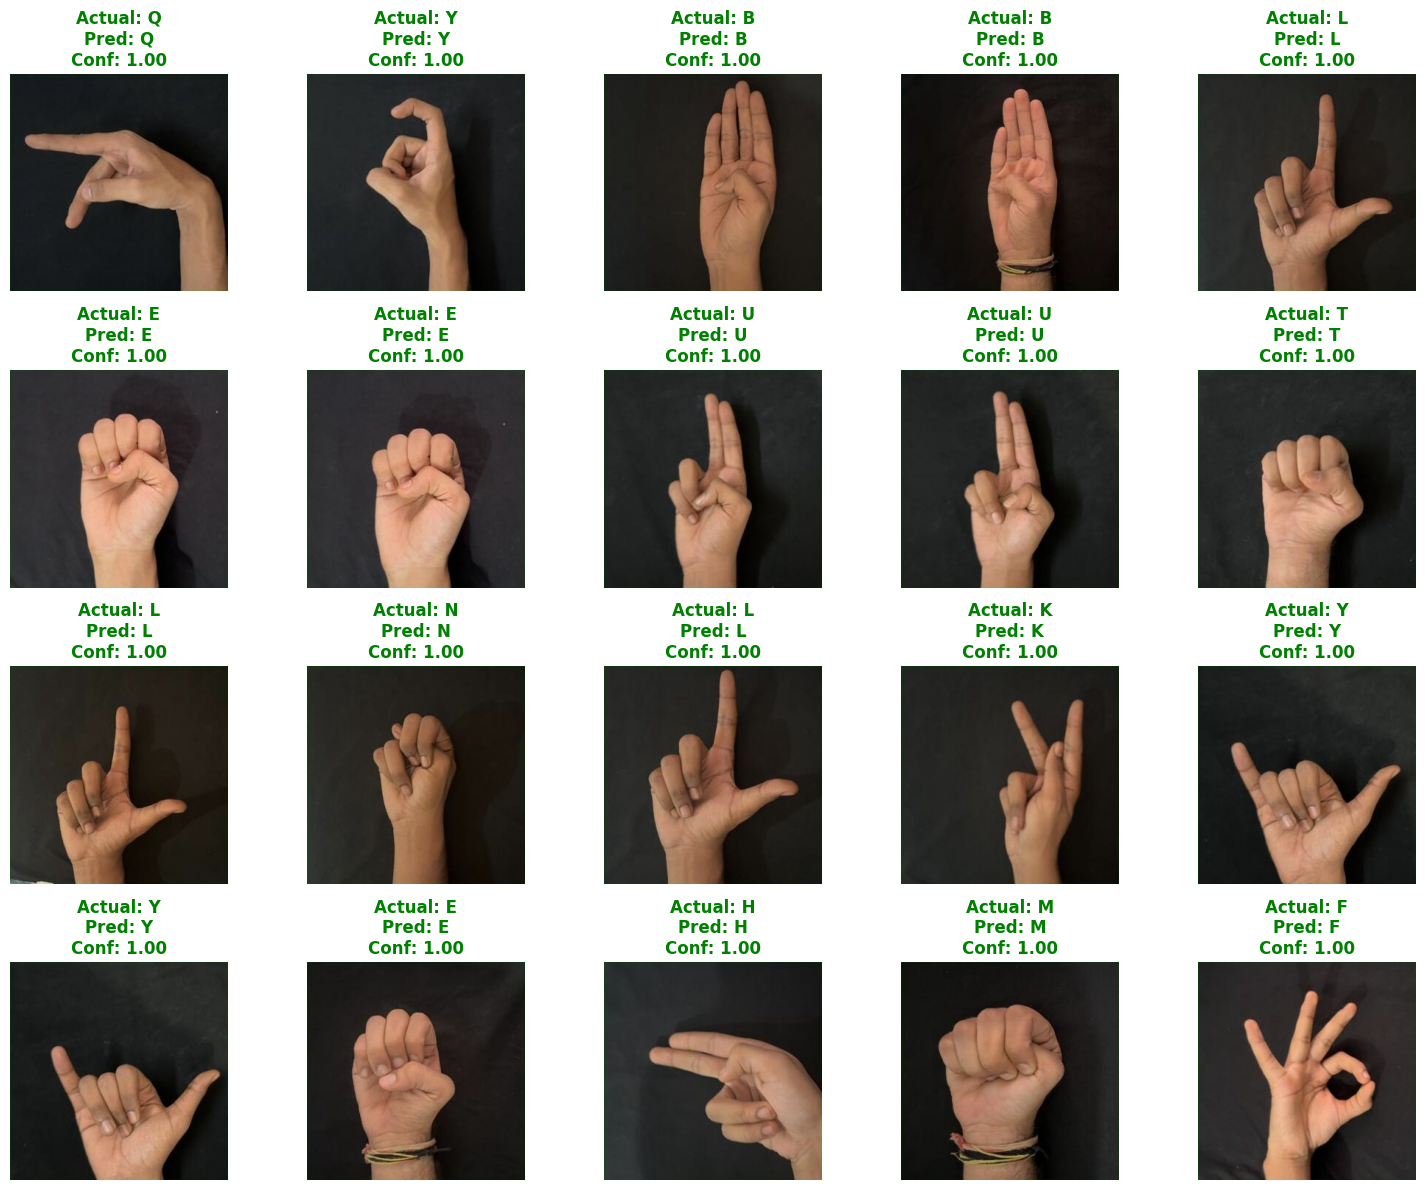


Correct Predictions: 2364/2364 (100.0%)

Incorrect Predictions:


In [8]:
# make predictions on test set and visualize results
predictions = model.predict(test_landmarks, verbose=0)
predicted_labels_int = np.argmax(predictions, axis=1)
predicted_labels = np.array([static_label_names[i] for i in predicted_labels_int])

# Randomly sample test images
num_samples = min(20, len(test_images))
random_indices = np.random.choice(len(test_images), size=num_samples, replace=False)

# Display a grid of randomly sampled test images with predictions
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for plot_idx, img_idx in enumerate(random_indices):
    ax = axes[plot_idx]
    ax.imshow(test_images[img_idx])
    
    actual = test_labels[img_idx]
    predicted = predicted_labels[img_idx]
    confidence = predictions[img_idx][predicted_labels_int[img_idx]]
    
    # Color green if correct, red if incorrect
    color = 'green' if actual == predicted else 'red'
    title = f"Actual: {actual}\nPred: {predicted}\nConf: {confidence:.2f}"
    ax.set_title(title, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Print summary statistics
correct = (predicted_labels == test_labels).sum()
total = len(test_labels)
print(f"\nCorrect Predictions: {correct}/{total} ({100*correct/total:.1f}%)")
print(f"\nIncorrect Predictions:")
incorrect_mask = predicted_labels != test_labels
incorrect_indices = np.where(incorrect_mask)[0]
for idx in incorrect_indices[:10]:  # Show first 10 incorrect predictions
    print(f"  Image {idx}: Actual='{test_labels[idx]}', Predicted='{predicted_labels[idx]}' (confidence: {predictions[idx][predicted_labels_int[idx]]:.3f})")